In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from river import tree
from river import metrics
from river import preprocessing

In [16]:
# Replace these with your actual file paths (CSV or Excel)
df = pd.read_csv("imputation_results.csv")

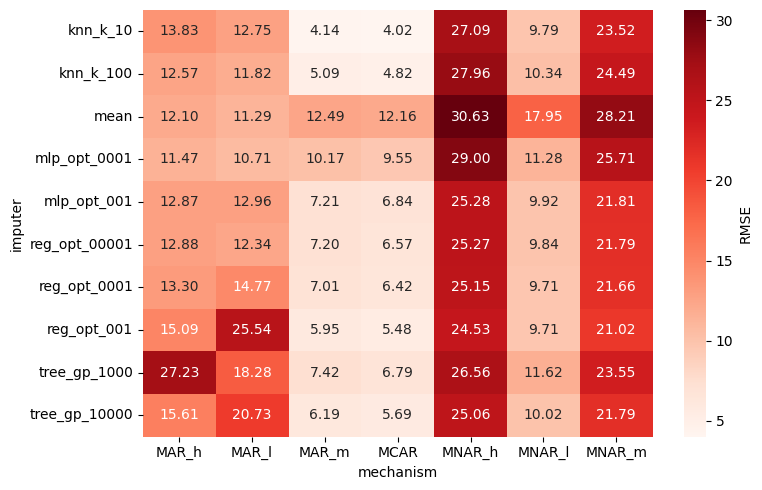

In [27]:
# pivot RMSE by mechanism (rows) and imputer (columns) and plot a heatmap (average over missing_rate)
pivot = df.pivot_table(index='imputer', columns=['mechanism'], values='rmse', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

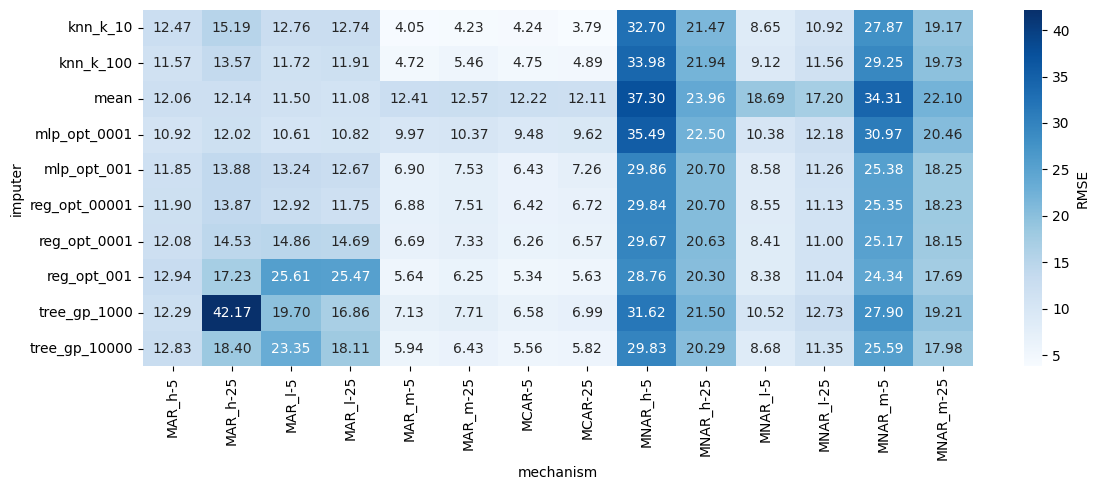

In [26]:
# pivot RMSE by mechanism (rows) and imputer (columns) and plot a heatmap (average over missing_rate)
pivot = df.pivot_table(index='imputer', columns=['mechanism','missing_rate'], values='rmse', aggfunc='mean')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

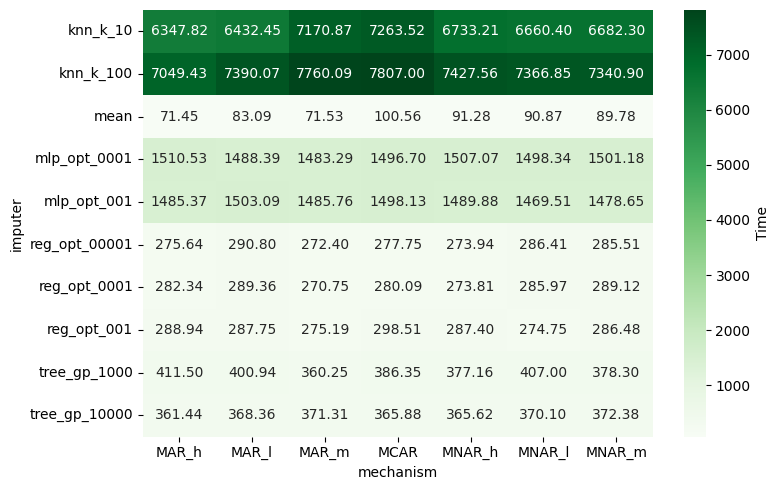

In [21]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

In [9]:
# Select best models for each method (knn, reg, tree, mlp)
# Best = lowest average RMSE across all mechanisms and missing rates

# Group imputers by method type
knn_imputers = [col for col in df['imputer'].unique() if 'knn' in col]
reg_imputers = [col for col in df['imputer'].unique() if 'reg' in col]
tree_imputers = [col for col in df['imputer'].unique() if 'tree' in col]
mlp_imputers = [col for col in df['imputer'].unique() if 'mlp' in col]
mean_imputers = [col for col in df['imputer'].unique() if 'mean' in col]

# Calculate average RMSE for each imputer
avg_rmse = df.groupby('imputer')['rmse'].mean().sort_values()

print("Best model for each method:\n")
print(f"KNN: {avg_rmse[avg_rmse.index.isin(knn_imputers)].idxmin()} (RMSE: {avg_rmse[avg_rmse.index.isin(knn_imputers)].min():.2f})")
print(f"REG: {avg_rmse[avg_rmse.index.isin(reg_imputers)].idxmin()} (RMSE: {avg_rmse[avg_rmse.index.isin(reg_imputers)].min():.2f})")
print(f"TREE: {avg_rmse[avg_rmse.index.isin(tree_imputers)].idxmin()} (RMSE: {avg_rmse[avg_rmse.index.isin(tree_imputers)].min():.2f})")
print(f"MLP: {avg_rmse[avg_rmse.index.isin(mlp_imputers)].idxmin()} (RMSE: {avg_rmse[avg_rmse.index.isin(mlp_imputers)].min():.2f})")
print(f"MEAN: {avg_rmse[avg_rmse.index.isin(mean_imputers)].idxmin()} (RMSE: {avg_rmse[avg_rmse.index.isin(mean_imputers)].min():.2f})")

# Create a dataframe with only the best models
best_imputers = [
    avg_rmse[avg_rmse.index.isin(knn_imputers)].idxmin(),
    avg_rmse[avg_rmse.index.isin(reg_imputers)].idxmin(),
    avg_rmse[avg_rmse.index.isin(tree_imputers)].idxmin(),
    avg_rmse[avg_rmse.index.isin(mlp_imputers)].idxmin(),
    avg_rmse[avg_rmse.index.isin(mean_imputers)].idxmin()
]

df_best = df[df['imputer'].isin(best_imputers)]
print(f"\nFiltered dataframe with best models: {len(df_best)} rows")

Best model for each method:

KNN: knn_k_10 (RMSE: 13.59)
REG: reg_opt_00001 (RMSE: 13.70)
TREE: tree_gp_10000 (RMSE: 15.01)
MLP: mlp_opt_001 (RMSE: 13.84)
MEAN: mean (RMSE: 17.83)

Filtered dataframe with best models: 70 rows


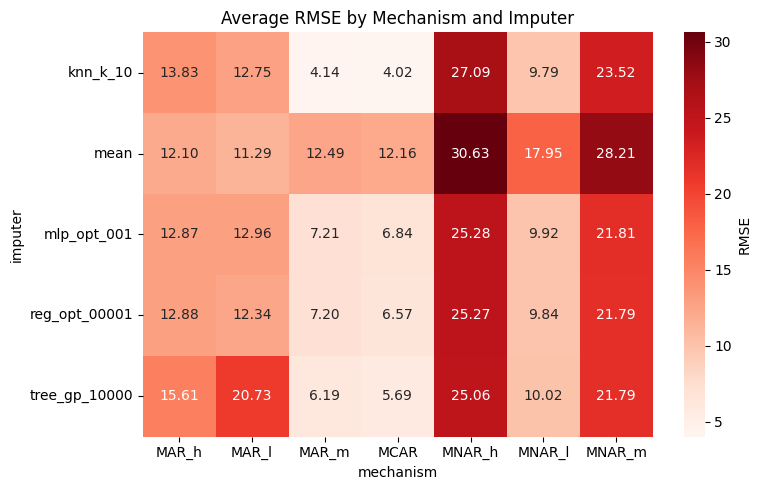

In [ ]:
pivot = df_best.pivot_table(index='imputer', columns='mechanism', values='rmse', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

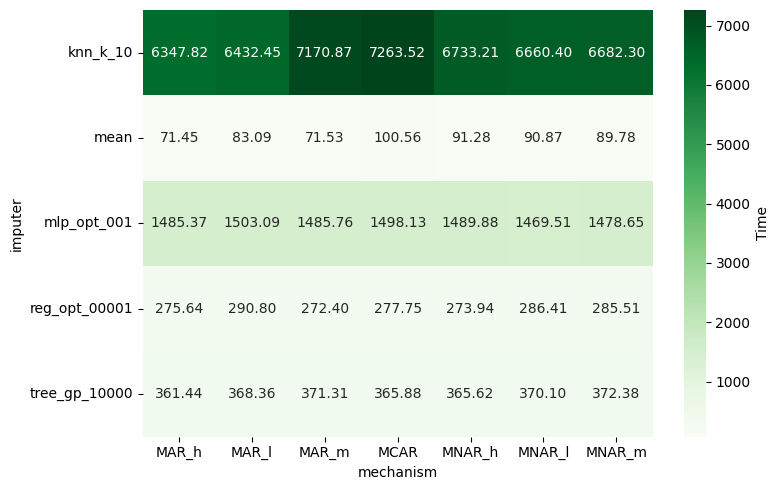

In [22]:
pivot = df_best.pivot_table(index='imputer', columns='mechanism', values='time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()